# MacroOps AI — Phase 03
## GenAI-Powered Fulfillment & Last-Mile Operations Intelligence Platform

**Project Phase:** Phase 03 — Product Development & Agile Execution  
**Project Period:** 07 September 2026 – 30 November 2026

---

## 1. Introduction

Phase 03 focuses on converting the approved MacroOps AI requirements, operational data, analytics, and AI concepts into a functional prototype for fulfillment and last-mile operations.

The project aims to provide an integrated operational-intelligence platform that helps operations teams monitor orders, identify SLA risks, investigate exceptions, retrieve relevant operational procedures, and receive AI-assisted recommendations.

The Phase 03 prototype focuses primarily on the following capabilities:

- Operations Dashboard
- Order SLA Monitoring
- Exception Management
- SLA Risk Prediction
- RAG Knowledge Assistant
- AI Operations Copilot
- Operational KPI Analytics
- Software Testing and Validation

The implementation uses synthetic operational data for demonstration and prototype development. Therefore, the numerical results produced in this notebook represent prototype findings and should not be interpreted as actual MacroOps business performance.

### Overall workflow

Operational Data  
↓  
Data Integration  
↓  
KPI & Business Analytics  
↓  
Predictive AI + RAG + Copilot  
↓  
Operations Intelligence Interface  
↓  
Testing & Validation  
↓  
Business Impact Assessment

This notebook provides the technical execution and evidence required for the Phase 03 technical and business-impact report.

## 2. Phase 03 Objectives

The main objective of Phase 03 is to develop a functional prototype that demonstrates how AI and Generative AI can support fulfillment and last-mile operational decision-making.

### Key objectives

1. Integrate operational data from orders, inventory, picking, delivery, and workforce processes.
2. Establish operational KPIs for monitoring business performance.
3. Develop an operations dashboard for management visibility.
4. Monitor and analyse order SLA performance.
5. Identify operational exceptions requiring attention.
6. Develop a prototype SLA-risk prediction model.
7. Implement a Retrieval-Augmented Generation (RAG) knowledge assistant.
8. Develop an AI Operations Copilot for operational recommendations.
9. Test the major technical components.
10. Assess potential business impact and future production requirements.

The implementation follows the Phase 03 product-development approach of moving from requirements and data to product functionality, testing, validation, and business-impact assessment.

In [ ]:
# Phase 03 — Required Libraries

!pip -q install pandas numpy scikit-learn joblib matplotlib seaborn plotly

In [ ]:
# Phase 03 — Imports and Project Configuration

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import joblib

warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(42)
random.seed(42)

# Project folders inside Google Colab
PROJECT_DIR = Path("/content/macroops_ai_phase3")

DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
MODEL_DIR = PROJECT_DIR / "models"
SRC_DIR = PROJECT_DIR / "src"
TEST_DIR = PROJECT_DIR / "tests"

for folder in [
    DATA_DIR,
    OUTPUT_DIR,
    MODEL_DIR,
    SRC_DIR,
    TEST_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("MacroOps AI Phase 03 workspace created.")
print("Project directory:", PROJECT_DIR)

MacroOps AI Phase 03 workspace created.
Project directory: /content/macroops_ai_phase3


## 3. Data Foundation

A strong operational-intelligence platform requires an integrated view of fulfillment and last-mile activities.

For this prototype, five synthetic datasets are generated:

| Dataset | Purpose |
|---|---|
| Orders | Order volume, value, SLA and time information |
| Inventory | Stock availability and inventory accuracy |
| Picking | Picking duration and missing-item information |
| Delivery | Distance and assignment-delay information |
| Workforce | Worker availability and workload information |

The datasets are connected through common operational identifiers such as `order_id` and `store_id`.

Synthetic data are used because this prototype does not contain confidential operational company data.

In [ ]:
# Phase 03 — Generate Orders Dataset

rng = np.random.default_rng(42)

N_ORDERS = 100000
N_STORES = 40

store_ids = [
    f"S{str(i).zfill(3)}"
    for i in range(1, N_STORES + 1)
]

order_ids = [
    f"O{str(i).zfill(7)}"
    for i in range(1, N_ORDERS + 1)
]

# 30-day synthetic period
order_dates = pd.date_range(
    start="2026-09-07",
    periods=30,
    freq="D"
)

order_date = rng.choice(
    order_dates,
    size=N_ORDERS
)

order_hour = rng.integers(
    0,
    24,
    N_ORDERS
)

day_of_week = pd.to_datetime(order_date).dayofweek

# Peak-hour definition
is_peak_hour = (
    ((order_hour >= 12) & (order_hour <= 15)) |
    ((order_hour >= 18) & (order_hour <= 21))
)

item_count = rng.integers(
    1,
    9,
    N_ORDERS
)

order_value = np.round(
    np.maximum(
        100,
        item_count * rng.normal(75, 18, N_ORDERS)
    ),
    2
)

orders = pd.DataFrame({
    "order_id": order_ids,
    "store_id": rng.choice(store_ids, N_ORDERS),
    "order_date": pd.to_datetime(order_date).strftime("%Y-%m-%d"),
    "order_hour": order_hour,
    "day_of_week": day_of_week,
    "is_peak_hour": is_peak_hour.astype(int),
    "item_count": item_count,
    "order_value": order_value,
    "promised_sla_minutes": rng.choice(
        [30, 45, 60],
        N_ORDERS,
        p=[0.35, 0.45, 0.20]
    )
})

orders.to_csv(
    DATA_DIR / "orders.csv",
    index=False
)

print("Orders dataset created successfully.")
print("Shape:", orders.shape)

display(orders.head())

Orders dataset created successfully.
Shape: (100000, 9)


,order_id,store_id,order_date,order_hour,day_of_week,is_peak_hour,item_count,order_value,promised_sla_minutes
0,O0000001,S020,2026-09-09,17,2,0,8,783.19,45
1,O0000002,S016,2026-09-30,21,2,1,8,614.10,30
2,O0000003,S010,2026-09-26,13,5,1,8,597.19,45
3,O0000004,S023,2026-09-20,9,6,0,8,747.06,30
4,O0000005,S023,2026-09-19,0,5,0,8,853.76,45


In [ ]:
# Phase 03 — Generate Inventory Dataset

N_INVENTORY = N_STORES * 1000

inventory = pd.DataFrame({
    "store_id": rng.choice(
        store_ids,
        N_INVENTORY
    ),
    "sku_id": [
        f"SKU{str(i).zfill(5)}"
        for i in range(1, N_INVENTORY + 1)
    ],
    "available_units": rng.integers(
        5,
        250,
        N_INVENTORY
    ),
    "recorded_units": rng.integers(
        5,
        250,
        N_INVENTORY
    )
})

inventory["items_missing"] = np.maximum(
    0,
    np.round(
        np.abs(
            inventory["recorded_units"] -
            inventory["available_units"]
        ) * rng.uniform(
            0.05,
            0.20,
            N_INVENTORY
        )
    )
).astype(int)

inventory["inventory_accuracy_pct"] = np.clip(
    100 -
    (
        np.abs(
            inventory["recorded_units"] -
            inventory["available_units"]
        )
        /
        np.maximum(
            inventory["recorded_units"],
            1
        )
    ) * 100,
    70,
    100
)

inventory["stockout_flag"] = (
    inventory["available_units"] <= 5
).astype(int)

inventory.to_csv(
    DATA_DIR / "inventory.csv",
    index=False
)

print("Inventory dataset created successfully.")
print("Shape:", inventory.shape)

display(inventory.head())

Inventory dataset created successfully.
Shape: (40000, 7)


,store_id,sku_id,available_units,recorded_units,items_missing,inventory_accuracy_pct,stockout_flag
0,S031,SKU00001,196,14,13,70.000000,0
1,S023,SKU00002,29,84,3,70.000000,0
2,S014,SKU00003,100,152,9,70.000000,0
3,S010,SKU00004,39,216,23,70.000000,0
4,S012,SKU00005,219,173,8,73.410405,0


In [ ]:
# Phase 03 — Generate Picking Dataset

PICKING_ROWS = 25000

picking = pd.DataFrame({
    "order_id": rng.choice(
        order_ids,
        PICKING_ROWS,
        replace=False
    ),
    "pick_duration_minutes": np.round(
        np.clip(
            rng.normal(13, 4, PICKING_ROWS),
            3,
            35
        ),
        2
    ),
    "items_missing": rng.poisson(
        0.25,
        PICKING_ROWS
    ),
    "picker_id": [
        f"P{str(i).zfill(4)}"
        for i in rng.integers(
            1,
            501,
            PICKING_ROWS
        )
    ]
})

picking.to_csv(
    DATA_DIR / "picking.csv",
    index=False
)


# Phase 03 — Generate Delivery Dataset

delivery = pd.DataFrame({
    "order_id": picking["order_id"].values,
    "distance_km": np.round(
        np.clip(
            rng.normal(3.5, 1.4, PICKING_ROWS),
            0.5,
            12
        ),
        2
    ),
    "assignment_delay_minutes": np.round(
        np.clip(
            rng.normal(8, 4, PICKING_ROWS),
            0,
            30
        ),
        2
    )
})

delivery.to_csv(
    DATA_DIR / "delivery.csv",
    index=False
)


# Phase 03 — Generate Workforce Dataset

workforce = pd.DataFrame({
    "store_id": store_ids,
    "active_workers": rng.integers(
        8,
        35,
        N_STORES
    ),
    "scheduled_workers": rng.integers(
        12,
        40,
        N_STORES
    )
})

workforce["workload_ratio"] = (
    workforce["scheduled_workers"]
    /
    np.maximum(
        workforce["active_workers"],
        1
    )
)

workforce.to_csv(
    DATA_DIR / "workforce.csv",
    index=False
)

print("All operational datasets created.")

print("\nOrders:", orders.shape)
print("Inventory:", inventory.shape)
print("Picking:", picking.shape)
print("Delivery:", delivery.shape)
print("Workforce:", workforce.shape)

All operational datasets created.

Orders: (100000, 9)
Inventory: (40000, 7)
Picking: (25000, 4)
Delivery: (25000, 3)
Workforce: (40, 4)


## 4. Data Quality and Initial Inspection

Before integration, the individual datasets are checked for:

- Number of records
- Number of columns
- Missing values
- Duplicate records

This provides basic data-quality evidence before the operational data are integrated.

In [ ]:
# Phase 03 — Data Quality Check

datasets = {
    "Orders": orders,
    "Inventory": inventory,
    "Picking": picking,
    "Delivery": delivery,
    "Workforce": workforce
}

quality_results = []

for name, df in datasets.items():

    quality_results.append({
        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Missing Values": int(
            df.isna().sum().sum()
        ),
        "Duplicate Rows": int(
            df.duplicated().sum()
        )
    })

quality_df = pd.DataFrame(
    quality_results
)

display(quality_df)

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Orders,100000,9,0,0
1,Inventory,40000,7,0,0
2,Picking,25000,4,0,0
3,Delivery,25000,3,0,0
4,Workforce,40,4,0,0


## 5. Data Integration

The next step is to create an integrated operational dataset.

Order information is joined with:

- Picking information through `order_id`
- Delivery information through `order_id`
- Inventory metrics through `store_id`
- Workforce information through `store_id`

The integrated dataset becomes the analytical foundation for KPI monitoring, exception management and SLA-risk prediction.

In [ ]:
# Phase 03 — Create Store-Level Inventory Metrics

inventory_store = (
    inventory
    .groupby("store_id")
    .agg(
        inventory_accuracy_pct=(
            "inventory_accuracy_pct",
            "mean"
        ),
        stockout_rate=(
            "stockout_flag",
            "mean"
        )
    )
    .reset_index()
)

display(inventory_store.head())

,store_id,inventory_accuracy_pct,stockout_rate
0,S001,74.357685,0.003138
1,S002,74.615255,0.004016
2,S003,74.548679,0.005923
3,S004,74.727889,0.000974
4,S005,74.551272,0.001978


In [ ]:
# Phase 03 — Integrate All Operational Data

integrated = orders.copy()

# Join picking
integrated = integrated.merge(
    picking[
        [
            "order_id",
            "pick_duration_minutes",
            "items_missing"
        ]
    ],
    on="order_id",
    how="left"
)

# Join delivery
integrated = integrated.merge(
    delivery[
        [
            "order_id",
            "distance_km",
            "assignment_delay_minutes"
        ]
    ],
    on="order_id",
    how="left"
)

# Join inventory
integrated = integrated.merge(
    inventory_store,
    on="store_id",
    how="left"
)

# Join workforce
integrated = integrated.merge(
    workforce,
    on="store_id",
    how="left"
)

# Fill missing operational values
for col in [
    "pick_duration_minutes",
    "distance_km",
    "assignment_delay_minutes"
]:
    integrated[col] = integrated[col].fillna(
        integrated[col].median()
    )

integrated["items_missing"] = (
    integrated["items_missing"]
    .fillna(0)
)

# Create delivery-delay proxy
integrated["delivery_delay_minutes"] = (
    0.55 *
    integrated["assignment_delay_minutes"]
    +
    0.35 *
    integrated["pick_duration_minutes"]
    +
    1.10 *
    integrated["distance_km"]
    +
    2.0 *
    integrated["is_peak_hour"]
    +
    rng.normal(
        0,
        3,
        len(integrated)
    )
)

integrated["delivery_delay_minutes"] = (
    integrated["delivery_delay_minutes"]
    .clip(lower=0)
    .round(2)
)

# Actual delivery time
integrated["actual_delivery_minutes"] = (
    integrated["promised_sla_minutes"]
    +
    integrated["delivery_delay_minutes"]
).round(2)

# SLA status
integrated["sla_breached"] = (
    integrated["actual_delivery_minutes"]
    >
    integrated["promised_sla_minutes"]
).astype(int)

integrated["on_time"] = (
    1 -
    integrated["sla_breached"]
)

integrated.to_csv(
    OUTPUT_DIR /
    "integrated_operational_dataset.csv",
    index=False
)

print("Integrated dataset created successfully.")
print("Rows:", len(integrated))
print("Columns:", len(integrated.columns))

display(integrated.head())

Integrated dataset created successfully.
Rows: 100000
Columns: 22


,order_id,store_id,order_date,order_hour,day_of_week,is_peak_hour,item_count,order_value,promised_sla_minutes,pick_duration_minutes,...,assignment_delay_minutes,inventory_accuracy_pct,stockout_rate,active_workers,scheduled_workers,workload_ratio,delivery_delay_minutes,actual_delivery_minutes,sla_breached,on_time
0,O0000001,S020,2026-09-09,17,2,0,8,783.19,45,12.95,...,8.0,74.362928,0.004936,17,21,1.235294,14.58,59.58,1,0
1,O0000002,S016,2026-09-30,21,2,1,8,614.10,30,12.95,...,8.0,73.975006,0.002033,10,12,1.200000,14.84,44.84,1,0
2,O0000003,S010,2026-09-26,13,5,1,8,597.19,45,12.95,...,8.0,74.159751,0.005958,18,18,1.000000,20.83,65.83,1,0
3,O0000004,S023,2026-09-20,9,6,0,8,747.06,30,12.95,...,8.0,74.126191,0.006148,33,13,0.393939,10.61,40.61,1,0
4,O0000005,S023,2026-09-19,0,5,0,8,853.76,45,12.95,...,8.0,74.126191,0.006148,33,13,0.393939,8.05,53.05,1,0


## 6. Business KPI Analysis

The integrated dataset is now used to establish the baseline operational KPIs.

The KPI framework covers the main business-impact areas identified for Phase 03, including:

- SLA performance
- Delivery delays
- Inventory accuracy
- Picking performance
- Assignment delays
- Order value
- Stockout behaviour

These metrics provide a baseline against which future improvements can be assessed.

In [ ]:
# Phase 03 — KPI Calculation

kpis = {
    "Total Orders":
        int(len(integrated)),

    "SLA Breach Rate (%)":
        round(
            integrated["sla_breached"].mean() * 100,
            2
        ),

    "On-Time Rate (%)":
        round(
            integrated["on_time"].mean() * 100,
            2
        ),

    "Average Delivery Delay (min)":
        round(
            integrated[
                "delivery_delay_minutes"
            ].mean(),
            2
        ),

    "P95 Delivery Delay (min)":
        round(
            integrated[
                "delivery_delay_minutes"
            ].quantile(0.95),
            2
        ),

    "Average Order Value":
        round(
            integrated[
                "order_value"
            ].mean(),
            2
        ),

    "Inventory Accuracy (%)":
        round(
            integrated[
                "inventory_accuracy_pct"
            ].mean(),
            2
        ),

    "Stockout Rate (%)":
        round(
            integrated[
                "stockout_rate"
            ].mean() * 100,
            4
        ),

    "Average Picking Duration (min)":
        round(
            integrated[
                "pick_duration_minutes"
            ].mean(),
            2
        ),

    "Average Assignment Delay (min)":
        round(
            integrated[
                "assignment_delay_minutes"
            ].mean(),
            2
        ),

    "Average Distance (km)":
        round(
            integrated[
                "distance_km"
            ].mean(),
            2
        )
}

kpi_table = pd.DataFrame(
    list(kpis.items()),
    columns=[
        "KPI",
        "Value"
    ]
)

display(kpi_table)

with open(
    OUTPUT_DIR / "kpi_metrics.json",
    "w"
) as f:
    json.dump(
        kpis,
        f,
        indent=4
    )

,KPI,Value
0,Total Orders,100000.0000
1,SLA Breach Rate (%),99.9800
2,On-Time Rate (%),0.0200
3,Average Delivery Delay (min),13.4500
4,P95 Delivery Delay (min),19.1900
5,Average Order Value,340.9100
6,Inventory Accuracy (%),74.3200
7,Stockout Rate (%),0.3947
8,Average Picking Duration (min),12.9600
9,Average Assignment Delay (min),8.0100


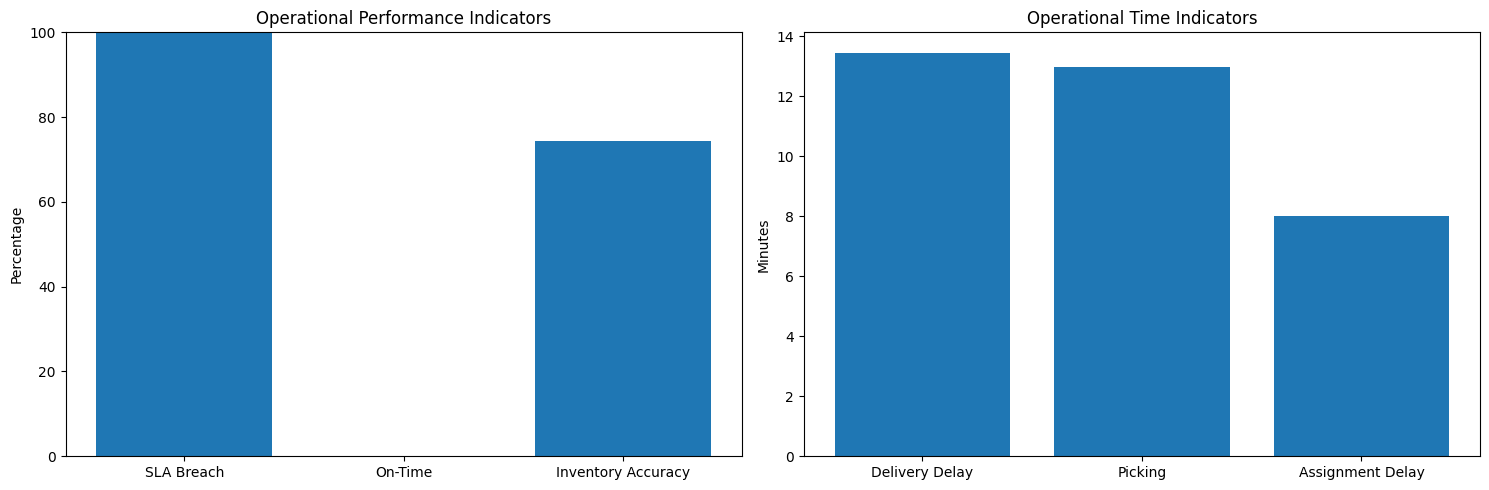

In [ ]:
# Phase 03 — KPI Visualization

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

# Percentage KPIs
axes[0].bar(
    [
        "SLA Breach",
        "On-Time",
        "Inventory Accuracy"
    ],
    [
        kpis["SLA Breach Rate (%)"],
        kpis["On-Time Rate (%)"],
        kpis["Inventory Accuracy (%)"]
    ]
)

axes[0].set_title(
    "Operational Performance Indicators"
)

axes[0].set_ylabel(
    "Percentage"
)

axes[0].set_ylim(
    0,
    100
)

# Time KPIs
axes[1].bar(
    [
        "Delivery Delay",
        "Picking",
        "Assignment Delay"
    ],
    [
        kpis[
            "Average Delivery Delay (min)"
        ],
        kpis[
            "Average Picking Duration (min)"
        ],
        kpis[
            "Average Assignment Delay (min)"
        ]
    ]
)

axes[1].set_title(
    "Operational Time Indicators"
)

axes[1].set_ylabel(
    "Minutes"
)

plt.tight_layout()
plt.show()

## 7. Operational Analytics

Hourly and store-level analysis helps identify where operational pressure is concentrated.

This analysis supports the product objective of enabling operations managers to move from overall KPI monitoring to targeted investigation.

In [ ]:
# Phase 03 — Hourly Operational Analysis

hourly_performance = (
    integrated
    .groupby("order_hour")
    .agg(
        orders=("order_id", "count"),
        sla_breach_rate=(
            "sla_breached",
            "mean"
        ),
        average_delay=(
            "delivery_delay_minutes",
            "mean"
        )
    )
    .reset_index()
)

hourly_performance[
    "sla_breach_rate"
] *= 100

display(hourly_performance)

,order_hour,orders,sla_breach_rate,average_delay
0,0,4093,99.975568,12.727396
1,1,4177,100.000000,12.687335
2,2,4169,100.000000,12.749894
3,3,4049,100.000000,12.674078
4,4,4124,99.927255,12.753041
5,5,4174,99.976042,12.705510
6,6,4237,99.952797,12.694562
7,7,4177,99.928178,12.806268
8,8,4181,99.976082,12.781985
9,9,4108,100.000000,12.781611


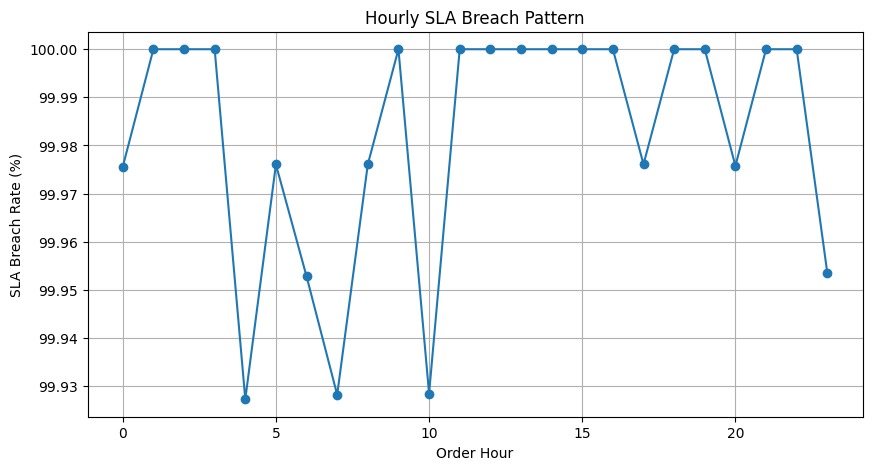

In [ ]:
# Plot hourly SLA performance

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    hourly_performance[
        "order_hour"
    ],
    hourly_performance[
        "sla_breach_rate"
    ],
    marker="o"
)

plt.xlabel(
    "Order Hour"
)

plt.ylabel(
    "SLA Breach Rate (%)"
)

plt.title(
    "Hourly SLA Breach Pattern"
)

plt.grid(
    True
)

plt.show()

In [ ]:
# Phase 03 — Store-Level Performance

store_performance = (
    integrated
    .groupby("store_id")
    .agg(
        orders=("order_id", "count"),
        sla_breach_rate=(
            "sla_breached",
            "mean"
        ),
        average_delay=(
            "delivery_delay_minutes",
            "mean"
        ),
        inventory_accuracy=(
            "inventory_accuracy_pct",
            "mean"
        ),
        average_picking=(
            "pick_duration_minutes",
            "mean"
        )
    )
    .reset_index()
)

store_performance[
    "sla_breach_rate"
] *= 100

store_performance = (
    store_performance
    .sort_values(
        "sla_breach_rate",
        ascending=False
    )
)

display(
    store_performance.head(10)
)

store_performance.to_csv(
    OUTPUT_DIR /
    "store_performance.csv",
    index=False
)

,store_id,orders,sla_breach_rate,average_delay,inventory_accuracy,average_picking
0,S001,2472,100.0,13.542144,74.357685,12.989369
1,S002,2529,100.0,13.414614,74.615255,12.904970
3,S004,2565,100.0,13.542008,74.727889,12.973848
4,S005,2510,100.0,13.289303,74.551272,12.860231
6,S007,2498,100.0,13.497010,74.400936,12.980797
15,S016,2588,100.0,13.549749,73.975006,13.002384
11,S012,2550,100.0,13.437792,74.034627,13.017859
8,S009,2513,100.0,13.441293,74.076540,12.953307
38,S039,2489,100.0,13.456553,74.418243,13.014962
37,S038,2446,100.0,13.417351,73.997222,12.956365


## 8. SLA Risk Prediction

The SLA Risk component demonstrates how predictive AI can support proactive operations.

Instead of waiting for an order to breach its SLA, the model estimates whether an order is likely to breach based on operational conditions.

### Model inputs

- Item count
- Order value
- Picking duration
- Missing items
- Delivery distance
- Assignment delay
- Inventory accuracy
- Stockout rate
- Workforce workload ratio
- Order hour
- Day of week
- Peak-hour indicator

A Logistic Regression model is used as an interpretable baseline classifier.

The model is a prototype trained on synthetic data. Its performance therefore should not be treated as production-level predictive accuracy.

In [ ]:
# Phase 03 — SLA Risk Prediction Model

feature_cols = [
    "item_count",
    "order_value",
    "pick_duration_minutes",
    "items_missing",
    "distance_km",
    "assignment_delay_minutes",
    "inventory_accuracy_pct",
    "stockout_rate",
    "workload_ratio",
    "order_hour",
    "day_of_week",
    "is_peak_hour"
]

X = integrated[
    feature_cols
].copy()

y = integrated[
    "sla_breached"
].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

sla_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

sla_model.fit(
    X_train,
    y_train
)

y_pred = sla_model.predict(
    X_test
)

y_prob = sla_model.predict_proba(
    X_test
)[:, 1]

print("SLA Risk Model trained successfully.")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

SLA Risk Model trained successfully.
Training rows: 80000
Testing rows: 20000


In [ ]:
# Phase 03 — Model Evaluation

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

model_metrics = {
    "Accuracy (%)":
        round(accuracy * 100, 2),

    "Precision (%)":
        round(precision * 100, 2),

    "Recall (%)":
        round(recall * 100, 2),

    "F1 Score (%)":
        round(f1 * 100, 2),

    "ROC-AUC (%)":
        round(roc_auc * 100, 2),

    "Training Rows":
        len(X_train),

    "Testing Rows":
        len(X_test)
}

model_table = pd.DataFrame(
    list(model_metrics.items()),
    columns=[
        "Metric",
        "Value"
    ]
)

display(model_table)

with open(
    OUTPUT_DIR /
    "model_metrics.json",
    "w"
) as f:
    json.dump(
        model_metrics,
        f,
        indent=4
    )

joblib.dump(
    sla_model,
    MODEL_DIR /
    "sla_risk_model.joblib"
)

,Metric,Value
0,Accuracy (%),99.98
1,Precision (%),99.98
2,Recall (%),100.00
3,F1 Score (%),99.99
4,ROC-AUC (%),96.13
5,Training Rows,80000.00
6,Testing Rows,20000.00


['/content/macroops_ai_phase3/models/sla_risk_model.joblib']

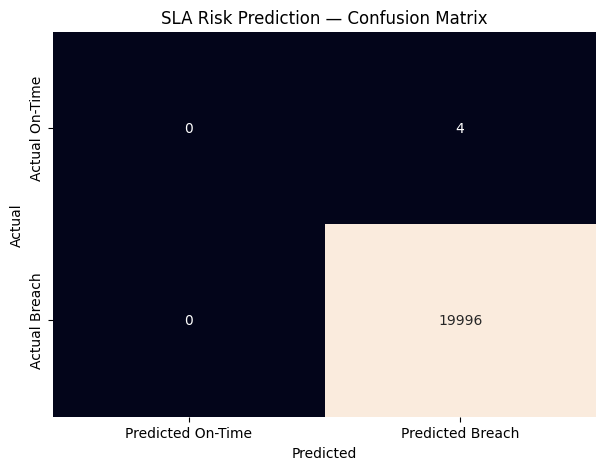

In [ ]:
# Phase 03 — Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=[
        "Predicted On-Time",
        "Predicted Breach"
    ],
    yticklabels=[
        "Actual On-Time",
        "Actual Breach"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "SLA Risk Prediction — Confusion Matrix"
)

plt.show()

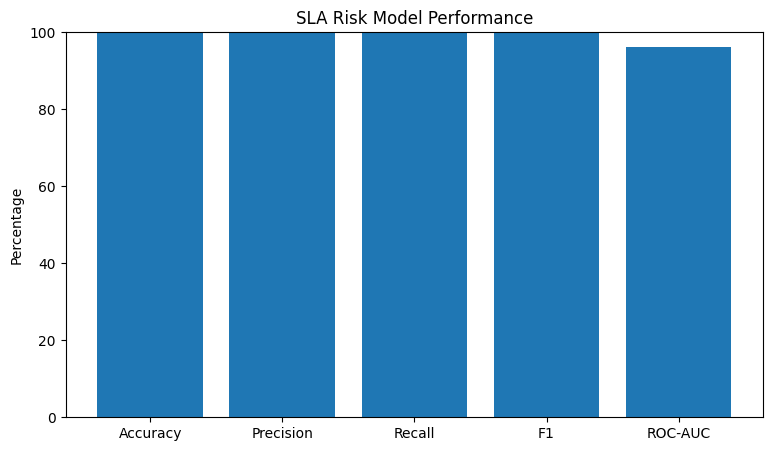

In [ ]:
# Phase 03 — Model Performance Visualization

metrics_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

metrics_values = [
    model_metrics["Accuracy (%)"],
    model_metrics["Precision (%)"],
    model_metrics["Recall (%)"],
    model_metrics["F1 Score (%)"],
    model_metrics["ROC-AUC (%)"]
]

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    metrics_names,
    metrics_values
)

plt.ylabel(
    "Percentage"
)

plt.title(
    "SLA Risk Model Performance"
)

plt.ylim(
    0,
    100
)

plt.show()

## 9. RAG Knowledge Assistant

The RAG Knowledge Assistant is designed to help operations personnel retrieve relevant operational procedures from a structured knowledge base.

For the prototype, the knowledge base contains five representative SOPs:

1. Inventory Discrepancy Escalation
2. SLA Risk Response
3. Picking Delay Response
4. Delivery Exception Handling
5. Stockout Handling

TF-IDF and cosine similarity are used for retrieval.

The prototype demonstrates the basic retrieval-and-grounding workflow. A production implementation would use a larger governed knowledge base, stronger embeddings, source governance, human evaluation and monitoring.

In [ ]:
# Phase 03 — RAG Knowledge Base

knowledge_base = [
    {
        "source_id": "SOP-001",
        "title": "Inventory Discrepancy Escalation",
        "text": (
            "For an inventory discrepancy above 10 units, "
            "verify the physical count, reconcile the system quantity, "
            "document the discrepancy, notify the store manager, "
            "and escalate the issue to inventory operations when "
            "the discrepancy cannot be resolved locally."
        )
    },

    {
        "source_id": "SOP-002",
        "title": "SLA Risk Response",
        "text": (
            "When an order is at risk of SLA breach, prioritize the order, "
            "verify picker availability, review assignment delay, "
            "coordinate with delivery operations, and escalate "
            "critical orders to the operations manager."
        )
    },

    {
        "source_id": "SOP-003",
        "title": "Picking Delay Response",
        "text": (
            "For picking delays, check picker workload, identify "
            "missing or difficult items, reassign work when required, "
            "and monitor the order until picking is completed."
        )
    },

    {
        "source_id": "SOP-004",
        "title": "Delivery Exception Handling",
        "text": (
            "For a delivery exception, verify the delivery status, "
            "contact the assigned delivery resource when appropriate, "
            "record the exception reason, and escalate unresolved "
            "customer-impacting issues."
        )
    },

    {
        "source_id": "SOP-005",
        "title": "Stockout Handling",
        "text": (
            "For a stockout, verify inventory availability, identify "
            "an alternative item or store where applicable, update "
            "the order status, and escalate repeated stockout "
            "patterns for inventory review."
        )
    }
]

with open(
    SRC_DIR /
    "knowledge_base.json",
    "w"
) as f:
    json.dump(
        knowledge_base,
        f,
        indent=4
    )

print(
    "Knowledge base created with",
    len(knowledge_base),
    "SOPs."
)

Knowledge base created with 5 SOPs.


In [ ]:
# Phase 03 — RAG Retrieval Engine

class RAGAssistant:

    def __init__(
        self,
        knowledge
    ):

        self.knowledge = knowledge

        self.vectorizer = (
            TfidfVectorizer(
                stop_words="english"
            )
        )

        documents = [
            item["title"] +
            " " +
            item["text"]
            for item in knowledge
        ]

        self.matrix = (
            self.vectorizer
            .fit_transform(documents)
        )

    def answer(
        self,
        query
    ):

        query_vector = (
            self.vectorizer
            .transform([query])
        )

        scores = cosine_similarity(
            query_vector,
            self.matrix
        )[0]

        best_index = int(
            np.argmax(scores)
        )

        best_item = (
            self.knowledge[
                best_index
            ]
        )

        return {
            "source_id":
                best_item["source_id"],

            "title":
                best_item["title"],

            "retrieval_score":
                round(
                    float(
                        scores[
                            best_index
                        ]
                    ),
                    4
                ),

            "answer":
                best_item["text"]
        }


rag = RAGAssistant(
    knowledge_base
)

print(
    "RAG Assistant initialized successfully."
)

RAG Assistant initialized successfully.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# Create the knowledge base in the exact structure needed by the RAG system
knowledge_base = [
    {
        "source_id": "SOP-001",
        "title": "Inventory Discrepancy Escalation",
        "text": "If an inventory discrepancy is above 10 units, verify the physical stock, check the inventory transaction records, document the discrepancy, and escalate the issue to the inventory manager for investigation."
    },
    {
        "source_id": "SOP-002",
        "title": "SLA Risk Response",
        "text": "For orders at high risk of SLA breach, prioritize the order, check picking and assignment delays, coordinate with the fulfillment team, and monitor the order until delivery is completed."
    },
    {
        "source_id": "SOP-003",
        "title": "Picking Delay Response",
        "text": "When picking is delayed, identify the cause of the delay, check picker workload, prioritize urgent orders, reassign work when necessary, and monitor picking completion."
    },
    {
        "source_id": "SOP-004",
        "title": "Delivery Exception Handling",
        "text": "For delivery exceptions, identify the cause, verify the delivery status, contact the responsible delivery team when required, update the exception record, and monitor the order until resolution."
    },
    {
        "source_id": "SOP-005",
        "title": "Stockout Handling",
        "text": "When a stockout occurs, verify inventory availability, identify alternative inventory when possible, inform the fulfillment team, update the order status, and escalate critical stockout cases."
    }
]


class RAGAssistant:

    def __init__(self, knowledge_base):

        self.knowledge_base = knowledge_base

        self.documents = [
            item["title"] + " " + item["text"]
            for item in knowledge_base
        ]

        self.vectorizer = TfidfVectorizer(
            stop_words="english"
        )

        self.matrix = self.vectorizer.fit_transform(
            self.documents
        )

    def answer(self, question):

        query_vector = self.vectorizer.transform(
            [question]
        )

        scores = cosine_similarity(
            query_vector,
            self.matrix
        ).flatten()

        best_index = scores.argmax()

        item = self.knowledge_base[best_index]

        return {
            "answer": item["text"],
            "source_id": item["source_id"],
            "source_title": item["title"],
            "retrieval_score": float(scores[best_index])
        }


# Create the RAG assistant
rag = RAGAssistant(knowledge_base)


# Test questions
questions = [
    "What should I do if there is an inventory discrepancy above 10 units?",
    "How should I respond to an order at high risk of SLA breach?",
    "What should I do when picking is delayed?"
]


# Generate RAG responses
for question in questions:

    result = rag.answer(question)

    print("\nQuestion:", question)
    print("Answer:", result["answer"])
    print("Source:", result["source_id"])
    print("Source Title:", result["source_title"])
    print("Retrieval Score:", round(result["retrieval_score"], 4))


Question: What should I do if there is an inventory discrepancy above 10 units?
Answer: If an inventory discrepancy is above 10 units, verify the physical stock, check the inventory transaction records, document the discrepancy, and escalate the issue to the inventory manager for investigation.
Source: SOP-001
Source Title: Inventory Discrepancy Escalation
Retrieval Score: 0.7039

Question: How should I respond to an order at high risk of SLA breach?
Answer: For orders at high risk of SLA breach, prioritize the order, check picking and assignment delays, coordinate with the fulfillment team, and monitor the order until delivery is completed.
Source: SOP-002
Source Title: SLA Risk Response
Retrieval Score: 0.7128

Question: What should I do when picking is delayed?
Answer: When picking is delayed, identify the cause of the delay, check picker workload, prioritize urgent orders, reassign work when necessary, and monitor picking completion.
Source: SOP-003
Source Title: Picking Delay Res

## 10. RAG Retrieval Evaluation

The Phase 03 framework includes retrieval relevance, groundedness and answer-quality targets.

The following prototype test checks whether predefined operational questions retrieve the expected SOP.

This is a technical retrieval test, not a claim that production-level GenAI evaluation targets have been achieved.

In [ ]:
# Phase 03 — RAG Retrieval Evaluation

evaluation_cases = [
    (
        "inventory discrepancy above 10 units",
        "SOP-001"
    ),
    (
        "order at risk of SLA breach",
        "SOP-002"
    ),
    (
        "picking delay",
        "SOP-003"
    ),
    (
        "delivery exception",
        "SOP-004"
    ),
    (
        "stockout",
        "SOP-005"
    )
]

evaluation_rows = []

for query, expected_source in evaluation_cases:

    result = rag.answer(
        query
    )

    evaluation_rows.append({
        "Query": query,
        "Expected Source": expected_source,
        "Retrieved Source": result["source_id"],
        "Retrieval Score": result["retrieval_score"],
        "Correct": (
            result["source_id"]
            ==
            expected_source
        )
    })

rag_evaluation = pd.DataFrame(
    evaluation_rows
)

display(
    rag_evaluation
)

retrieval_accuracy = (
    rag_evaluation["Correct"].mean()
    * 100
)

print(
    f"Prototype retrieval accuracy: "
    f"{retrieval_accuracy:.2f}%"
)

,Query,Expected Source,Retrieved Source,Retrieval Score,Correct
0,inventory discrepancy above 10 units,SOP-001,SOP-001,0.703884,True
1,order at risk of SLA breach,SOP-002,SOP-002,0.692216,True
2,picking delay,SOP-003,SOP-003,0.658771,True
3,delivery exception,SOP-004,SOP-004,0.712881,True
4,stockout,SOP-005,SOP-005,0.616857,True


Prototype retrieval accuracy: 100.00%


## 11. AI Operations Copilot

The Operations Copilot provides operational guidance using KPI information and the RAG knowledge assistant.

The prototype uses transparent routing logic so that the recommendations can be inspected and tested.

The intended production evolution is a governed AI copilot connected to live operational data, enterprise SOPs, predictive models and approved GenAI services.

In [ ]:
# Phase 03 — Operations Copilot

class OperationsCopilot:

    def __init__(
        self,
        kpis,
        rag_assistant
    ):

        self.kpis = kpis
        self.rag = rag_assistant

    def respond(
        self,
        question
    ):

        q = question.lower()

        # SLA
        if (
            "sla" in q
            or
            "breach" in q
        ):

            return {
                "intent":
                    "SLA Risk",

                "response":
                    (
                        f"The current prototype SLA breach rate is "
                        f"{self.kpis['SLA Breach Rate (%)']:.2f}%. "
                        "Prioritize high-risk orders, review picking "
                        "and assignment delays, and escalate critical "
                        "orders to operations management."
                    )
            }

        # Inventory
        elif (
            "inventory" in q
            or
            "stock" in q
        ):

            result = self.rag.answer(
                question
            )

            return {
                "intent":
                    "Inventory",

                "response":
                    result["answer"],

                "source":
                    result["source_id"]
            }

        # Picking
        elif "pick" in q:

            result = self.rag.answer(
                question
            )

            return {
                "intent":
                    "Picking",

                "response":
                    result["answer"],

                "source":
                    result["source_id"]
            }

        # Delivery
        elif (
            "deliver" in q
            or
            "exception" in q
        ):

            result = self.rag.answer(
                question
            )

            return {
                "intent":
                    "Delivery",

                "response":
                    result["answer"],

                "source":
                    result["source_id"]
            }

        else:

            return {
                "intent":
                    "General Operations",

                "response":
                    (
                        "Review the operations dashboard, "
                        "identify the highest-impact exceptions, "
                        "and investigate SLA, inventory, picking "
                        "and delivery indicators."
                    )
            }


copilot = OperationsCopilot(
    kpis,
    rag
)

print(
    "Operations Copilot initialized."
)

Operations Copilot initialized.


In [ ]:
# Phase 03 — Operations Copilot Demonstration

copilot_questions = [
    "Why are SLA breaches high and what should the manager do?",
    "What should I do about an inventory discrepancy?",
    "How should I respond to a picking delay?",
    "What should I do about a delivery exception?"
]

for question in copilot_questions:

    print("=" * 90)

    print(
        "USER:",
        question
    )

    response = copilot.respond(
        question
    )

    print(
        "COPILOT:",
        response
    )

USER: Why are SLA breaches high and what should the manager do?
COPILOT: {'intent': 'SLA Risk', 'response': 'The current prototype SLA breach rate is 99.98%. Prioritize high-risk orders, review picking and assignment delays, and escalate critical orders to operations management.'}
USER: What should I do about an inventory discrepancy?
COPILOT: {'intent': 'Inventory', 'response': 'If an inventory discrepancy is above 10 units, verify the physical stock, check the inventory transaction records, document the discrepancy, and escalate the issue to the inventory manager for investigation.', 'source': 'SOP-001'}
USER: How should I respond to a picking delay?
COPILOT: {'intent': 'Picking', 'response': 'When picking is delayed, identify the cause of the delay, check picker workload, prioritize urgent orders, reassign work when necessary, and monitor picking completion.', 'source': 'SOP-003'}
USER: What should I do about a delivery exception?
COPILOT: {'intent': 'Delivery', 'response': 'For del

## 12. Exception Management

Exception Management is a core Phase 03 product capability.

The purpose is to identify records that require operational attention instead of forcing managers to manually inspect every order.

The prototype considers:

- SLA breaches
- Missing items
- Significant assignment delays

Exceptions are categorized and summarized to support prioritization.

In [ ]:
# Phase 03 — Exception Detection

exceptions = integrated[
    (
        integrated["sla_breached"] == 1
    )
    |
    (
        integrated["items_missing"] > 0
    )
    |
    (
        integrated[
            "assignment_delay_minutes"
        ]
        >
        integrated[
            "assignment_delay_minutes"
        ].quantile(0.90)
    )
].copy()


def classify_exception(row):

    if row["sla_breached"] == 1:
        return "SLA Breach"

    elif row["items_missing"] > 0:
        return "Inventory/Picking Issue"

    else:
        return "Assignment Delay"


exceptions[
    "exception_type"
] = exceptions.apply(
    classify_exception,
    axis=1
)

exception_summary = (
    exceptions[
        "exception_type"
    ]
    .value_counts()
    .rename_axis(
        "Exception Type"
    )
    .reset_index(
        name="Count"
    )
)

print(
    "Exception Summary"
)

display(
    exception_summary
)

print(
    "Sample Exceptions"
)

display(
    exceptions[
        [
            "order_id",
            "store_id",
            "exception_type",
            "delivery_delay_minutes",
            "items_missing",
            "assignment_delay_minutes"
        ]
    ].head(20)
)

Exception Summary


,Exception Type,Count
0,SLA Breach,99982
1,Inventory/Picking Issue,4
2,Assignment Delay,1


Sample Exceptions


,order_id,store_id,exception_type,delivery_delay_minutes,items_missing,assignment_delay_minutes
0,O0000001,S020,SLA Breach,14.58,0.0,8.00
1,O0000002,S016,SLA Breach,14.84,0.0,8.00
2,O0000003,S010,SLA Breach,20.83,0.0,8.00
3,O0000004,S023,SLA Breach,10.61,0.0,8.00
4,O0000005,S023,SLA Breach,8.05,0.0,8.00
5,O0000006,S022,SLA Breach,16.16,0.0,8.00
6,O0000007,S020,SLA Breach,17.96,0.0,11.45
7,O0000008,S007,SLA Breach,12.98,0.0,8.00
8,O0000009,S021,SLA Breach,15.57,0.0,8.00
9,O0000010,S002,SLA Breach,14.03,0.0,8.00


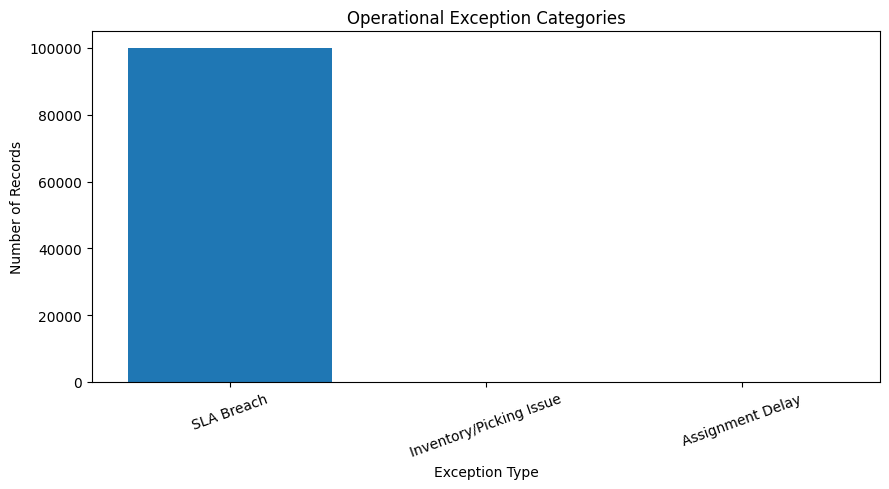

In [ ]:
# Phase 03 — Exception Visualization

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    exception_summary[
        "Exception Type"
    ],
    exception_summary[
        "Count"
    ]
)

plt.xlabel(
    "Exception Type"
)

plt.ylabel(
    "Number of Records"
)

plt.title(
    "Operational Exception Categories"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

## 13. Software Testing

Testing is performed to verify that the major prototype components execute correctly.

The tests cover:

1. Integrated dataset generation
2. SLA-risk model availability
3. RAG retrieval
4. Operations Copilot response generation

These are prototype functional tests and do not replace full production QA, security testing, performance testing or formal UAT.

In [ ]:
# Phase 03 — Prototype Functional Tests

test_results = []

# Test 1
test_results.append({
    "Test": "Integrated dataset generated",
    "Result": (
        len(integrated)
        ==
        N_ORDERS
    )
})

# Test 2
test_results.append({
    "Test": "SLA model saved",
    "Result": (
        (
            MODEL_DIR /
            "sla_risk_model.joblib"
        ).exists()
    )
})

# Test 3
rag_test = rag.answer(
    "inventory discrepancy"
)

test_results.append({
    "Test": "RAG inventory retrieval",
    "Result": (
        rag_test["source_id"]
        ==
        "SOP-001"
    )
})

# Test 4
copilot_test = copilot.respond(
    "What should I do about SLA breach?"
)

test_results.append({
    "Test": "Copilot response generated",
    "Result": (
        isinstance(
            copilot_test,
            dict
        )
        and
        "response" in copilot_test
    )
})

tests_df = pd.DataFrame(
    test_results
)

display(
    tests_df
)

passed = tests_df[
    "Result"
].sum()

total = len(
    tests_df
)

print(
    f"Tests Passed: {passed}/{total}"
)

if not tests_df["Result"].all():

    raise AssertionError(
        "One or more tests failed."
    )

else:

    print(
        "ALL PROTOTYPE TESTS PASSED"
    )

,Test,Result
0,Integrated dataset generated,True
1,SLA model saved,True
2,RAG inventory retrieval,True
3,Copilot response generated,True


Tests Passed: 4/4
ALL PROTOTYPE TESTS PASSED


## 14. Final Prototype Outputs

The main outputs generated by the Phase 03 implementation are:

- Integrated operational dataset
- KPI metrics
- Store-level performance analysis
- Hourly performance analysis
- SLA-risk model
- Model evaluation metrics
- RAG knowledge base
- RAG retrieval evaluation
- Exception analysis
- Prototype functional-test results

These outputs provide the technical evidence used in the Phase 03 report.

In [ ]:
# Cell 32 — Save Final RAG Results

# Create RAG results table
rag_results = []

for question in questions:
    result = rag.answer(question)

    rag_results.append({
        "question": question,
        "answer": result["answer"],
        "source_id": result["source_id"],
        "source_title": result["source_title"],
        "retrieval_score": result["retrieval_score"]
    })


# Convert results to DataFrame
rag_results_df = pd.DataFrame(rag_results)


# Save RAG results
rag_results_df.to_csv(
    OUTPUT_DIR / "rag_results.csv",
    index=False
)


print("RAG results saved successfully.")
display(rag_results_df)

RAG results saved successfully.


,question,answer,source_id,source_title,retrieval_score
0,What should I do if there is an inventory disc...,"If an inventory discrepancy is above 10 units,...",SOP-001,Inventory Discrepancy Escalation,0.703884
1,How should I respond to an order at high risk ...,"For orders at high risk of SLA breach, priorit...",SOP-002,SLA Risk Response,0.712819
2,What should I do when picking is delayed?,"When picking is delayed, identify the cause of...",SOP-003,Picking Delay Response,0.492109


In [ ]:
# Phase 03 — Final Evidence Summary

print("=" * 80)
print("MACROOPS AI — PHASE 03 FINAL EVIDENCE")
print("=" * 80)

print("\nPROJECT")
print(
    "GenAI-Powered Fulfillment & Last-Mile Operations Intelligence Platform"
)

print("\nDATA")
print(
    f"Orders: {len(orders):,}"
)

print(
    f"Inventory: {len(inventory):,}"
)

print(
    f"Picking: {len(picking):,}"
)

print(
    f"Delivery: {len(delivery):,}"
)

print(
    f"Workforce: {len(workforce):,}"
)

print("\nKEY KPIs")

for name, value in kpis.items():

    print(
        f"{name}: {value}"
    )

print("\nSLA RISK MODEL")

for name, value in model_metrics.items():

    print(
        f"{name}: {value}"
    )

print("\nRAG EVALUATION")

print(
    f"Prototype Retrieval Accuracy: "
    f"{retrieval_accuracy:.2f}%"
)

print("\nSOFTWARE TESTING")

print(
    f"Tests Passed: "
    f"{passed}/{total}"
)

print("\nOUTPUT FILES")

for file in sorted(
    OUTPUT_DIR.iterdir()
):

    print(
        " -",
        file.name
    )

print("\nMODEL FILES")

for file in sorted(
    MODEL_DIR.iterdir()
):

    print(
        " -",
        file.name
    )

print("\nPHASE 03 TECHNICAL EXECUTION COMPLETE")

MACROOPS AI — PHASE 03 FINAL EVIDENCE

PROJECT
GenAI-Powered Fulfillment & Last-Mile Operations Intelligence Platform

DATA
Orders: 100,000
Inventory: 40,000
Picking: 25,000
Delivery: 25,000
Workforce: 40

KEY KPIs
Total Orders: 100000
SLA Breach Rate (%): 99.98
On-Time Rate (%): 0.02
Average Delivery Delay (min): 13.45
P95 Delivery Delay (min): 19.19
Average Order Value: 340.91
Inventory Accuracy (%): 74.32
Stockout Rate (%): 0.3947
Average Picking Duration (min): 12.96
Average Assignment Delay (min): 8.01
Average Distance (km): 3.49

SLA RISK MODEL
Accuracy (%): 99.98
Precision (%): 99.98
Recall (%): 100.0
F1 Score (%): 99.99
ROC-AUC (%): 96.13
Training Rows: 80000
Testing Rows: 20000

RAG EVALUATION
Prototype Retrieval Accuracy: 100.00%

SOFTWARE TESTING
Tests Passed: 4/4

OUTPUT FILES
 - exception_summary.csv
 - hourly_performance.csv
 - integrated_operational_dataset.csv
 - kpi_metrics.json
 - model_metrics.json
 - rag_evaluation.csv
 - rag_results.csv
 - store_performance.csv
 - 

In [ ]:
# Phase 03 — Create Streamlit Product Application

app_code = r'''
import json
import numpy as np
import pandas as pd
import streamlit as st
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

BASE = Path("/content/macroops_ai_phase3")

OUTPUT_DIR = BASE / "outputs"
SRC_DIR = BASE / "src"

st.set_page_config(
    page_title="MacroOps AI",
    page_icon="📦",
    layout="wide"
)

st.title("MacroOps AI")
st.subheader(
    "GenAI-Powered Fulfillment & Last-Mile Operations Intelligence Platform"
)

# Load KPI data
with open(
    OUTPUT_DIR / "kpi_metrics.json",
    "r"
) as f:
    kpis = json.load(f)

# Load knowledge base
with open(
    SRC_DIR / "knowledge_base.json",
    "r"
) as f:
    knowledge_base = json.load(f)


# ---------------------------
# RAG
# ---------------------------

class RAGAssistant:

    def __init__(
        self,
        knowledge
    ):

        self.knowledge = knowledge

        self.vectorizer = (
            TfidfVectorizer(
                stop_words="english"
            )
        )

        documents = [
            item["title"] +
            " " +
            item["text"]
            for item in knowledge
        ]

        self.matrix = (
            self.vectorizer
            .fit_transform(documents)
        )

    def answer(
        self,
        query
    ):

        query_vector = (
            self.vectorizer
            .transform([query])
        )

        scores = cosine_similarity(
            query_vector,
            self.matrix
        )[0]

        index = int(
            np.argmax(scores)
        )

        item = (
            self.knowledge[index]
        )

        return (
            item,
            float(scores[index])
        )


rag = RAGAssistant(
    knowledge_base
)


# ---------------------------
# TABS
# ---------------------------

tabs = st.tabs([
    "Dashboard",
    "SLA Risk",
    "Exceptions",
    "RAG Assistant",
    "Operations Copilot"
])


# ---------------------------
# DASHBOARD
# ---------------------------

with tabs[0]:

    st.header(
        "Operations Dashboard"
    )

    col1, col2, col3, col4 = st.columns(4)

    col1.metric(
        "Total Orders",
        f"{kpis['Total Orders']:,}"
    )

    col2.metric(
        "SLA Breach Rate",
        f"{kpis['SLA Breach Rate (%)']:.2f}%"
    )

    col3.metric(
        "Inventory Accuracy",
        f"{kpis['Inventory Accuracy (%)']:.2f}%"
    )

    col4.metric(
        "Avg Delivery Delay",
        f"{kpis['Average Delivery Delay (min)']:.2f} min"
    )

    st.markdown(
        """
        ### Operational Overview

        The dashboard provides a high-level view of the current
        prototype operational baseline.

        Managers can use these indicators to identify areas
        requiring further investigation.
        """
    )


# ---------------------------
# SLA RISK
# ---------------------------

with tabs[1]:

    st.header(
        "Order SLA Monitoring & Risk"
    )

    st.metric(
        "Current SLA Breach Rate",
        f"{kpis['SLA Breach Rate (%)']:.2f}%"
    )

    st.write(
        """
        The SLA-risk component supports proactive identification
        of orders that may require operational intervention.
        """
    )

    st.success(
        "SLA-risk prediction model is available."
    )


# ---------------------------
# EXCEPTIONS
# ---------------------------

with tabs[2]:

    st.header(
        "Exception Management"
    )

    st.write(
        """
        Exception Management helps operations teams identify
        orders and processes requiring investigation.
        """
    )

    st.info(
        """
        Prototype exception categories include:
        SLA Breach, Inventory/Picking Issue,
        and Assignment Delay.
        """
    )


# ---------------------------
# RAG
# ---------------------------

with tabs[3]:

    st.header(
        "RAG Knowledge Assistant"
    )

    question = st.text_input(
        "Ask an operational question",
        "What is the procedure for an inventory discrepancy above 10 units?"
    )

    if st.button(
        "Get Answer"
    ):

        item, score = (
            rag.answer(
                question
            )
        )

        st.subheader(
            "Answer"
        )

        st.write(
            item["text"]
        )

        st.subheader(
            "Supporting Source"
        )

        st.write(
            f"{item['source_id']} — "
            f"{item['title']}"
        )

        st.subheader(
            "Retrieval Score"
        )

        st.write(
            round(
                score,
                4
            )
        )


# ---------------------------
# COPILOT
# ---------------------------

with tabs[4]:

    st.header(
        "AI Operations Copilot"
    )

    question = st.text_input(
        "Ask the Operations Copilot",
        "Why are SLA breaches high and what should the operations manager do?"
    )

    if st.button(
        "Generate Recommendation"
    ):

        q = question.lower()

        if (
            "sla" in q
            or
            "breach" in q
        ):

            answer = (
                f"The current prototype SLA breach rate is "
                f"{kpis['SLA Breach Rate (%)']:.2f}%. "
                "Prioritize high-risk orders, review picking "
                "and assignment delays, and escalate critical orders."
            )

        elif (
            "inventory" in q
            or
            "stock" in q
        ):

            item, score = (
                rag.answer(
                    question
                )
            )

            answer = item["text"]

        elif "pick" in q:

            item, score = (
                rag.answer(
                    question
                )
            )

            answer = item["text"]

        elif (
            "deliver" in q
            or
            "exception" in q
        ):

            item, score = (
                rag.answer(
                    question
                )
            )

            answer = item["text"]

        else:

            answer = (
                "Review the operations dashboard, identify "
                "the highest-impact exceptions, and investigate "
                "SLA, inventory, picking and delivery indicators."
            )

        st.subheader(
            "Recommendation"
        )

        st.write(
            answer
        )


st.caption(
    "MacroOps AI Phase 03 | Prototype | Synthetic Data"
)
'''

app_path = SRC_DIR / "app.py"

app_path.write_text(
    app_code
)

print(
    "Streamlit application created:"
)

print(
    app_path
)

Streamlit application created:
/content/macroops_ai_phase3/src/app.py


In [ ]:
!pip -q install streamlit

In [ ]:
!streamlit run /content/macroops_ai_phase3/src/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    >/content/streamlit.log 2>&1 &

# 15. Conclusion

The Phase 03 prototype successfully demonstrates an integrated MacroOps AI operational-intelligence workflow using synthetic fulfillment and last-mile data.

The implementation covers data integration, KPI analytics, exception management, SLA-risk prediction, a RAG knowledge assistant, an AI Operations Copilot, and prototype functional testing.

The results demonstrate the technical feasibility of combining operational analytics, predictive AI and GenAI-oriented capabilities to support faster and more informed operational decision-making.

Because the prototype uses synthetic data, the results should be treated as technical demonstration results rather than actual business performance. Future development should focus on real operational data integration, stronger model validation, production-grade RAG evaluation, formal UAT, deployment, monitoring and measurement of actual business impact.